# 04 · Results and comparison

Reads `results/*.json` and writes `results/RESULTS.md` plus the plots used in the README.

In [1]:
# --- Colab setup: GPU runtime (Runtime > Change runtime type > T4 GPU) ---
REPO_URL = "https://github.com/gaurkhare/gaurav-eagv5-s13.git"
import os, sys, json
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = "/content/drive/MyDrive/era_a13"          # data + results persist across notebooks
    if not os.path.exists("/content/repo"):
        !git clone -q {REPO_URL} /content/repo
    os.chdir("/content/repo")
else:
    WORK = os.path.abspath("..")                      # running locally from notebooks/
    os.chdir(WORK)
sys.path.insert(0, os.getcwd())
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
DATA_DIR, RESULTS = f"{WORK}/data", f"{WORK}/results"
os.makedirs(RESULTS, exist_ok=True)
!nvidia-smi --query-gpu=name,memory.total --format=csv 2>/dev/null || echo "no nvidia GPU"

Mounted at /content/drive
name, memory.total [MiB]
Tesla T4, 15360 MiB


In [2]:
import glob, shutil
import matplotlib.pyplot as plt

def load(f):
    return json.load(open(f"{RESULTS}/{f}")) if os.path.exists(f"{RESULTS}/{f}") else {}

runs = {n: load(f"{n}.json") for n in ["baseline", "reversible", "reversible_maxbatch"] if load(f"{n}.json")}
bj, vj, dep = load("batch.json"), load("variant.json"), load("mem_vs_depth.json")
rows = ["| run | residual | batch (seq × 512) | optimizer steps | final train loss | final val loss | tokens/s | peak mem alloc (GB) | peak mem reserved (GB) | wall time (min) |",
        "|---|---|---|---|---|---|---|---|---|---|"]
for n, r in runs.items():
    variant = "euler" if n == "baseline" else vj.get("best_variant", r["config"]["model"]["residual"])
    rows.append(f"| {n} | {variant} | {r['config']['batch_size']} | {r['steps']} | {r['final_train_loss']:.4f} | "
                f"{r['final_val_loss']:.4f} | {r['tokens_per_s']:,.0f} | {r['peak_mem_allocated_gb']:.2f} | "
                f"{r['peak_mem_reserved_gb']:.2f} | {r['wall_time_min']:.1f} |")
b = runs.get("baseline")
extra = []
if b:
    for n, r in runs.items():
        if n != "baseline":
            extra.append(f"- **{n}** vs baseline: throughput {r['tokens_per_s']/b['tokens_per_s']:.2f}×, "
                         f"peak memory {r['peak_mem_allocated_gb']/b['peak_mem_allocated_gb']:.2f}×, "
                         f"val loss {r['final_val_loss']-b['final_val_loss']:+.4f}")
drift = load("drift_init.json")
sweep = {os.path.basename(f)[len("sweep_"):-len(".json")]: json.load(open(f)) for f in sorted(glob.glob(f"{RESULTS}/sweep_*.json"))}
srows = ["| variant | val loss @5M tokens | tokens/s | peak mem (GB) | recon rel. err (init) | grad rel. err vs autograd (init) |",
         "|---|---|---|---|---|---|"]
for v, r in sweep.items():
    d = drift.get(v, {})
    srows.append(f"| {v} | {r['final_val_loss']:.4f} | {r['tokens_per_s']:,.0f} | {r['peak_mem_allocated_gb']:.2f} | "
                 f"{d.get('recon_rel_err', float('nan')):.2e} | {d.get('grad_rel_err', float('nan')):.2%} |")
mem = load("mem_at_fixed_batch.json")
mrows = ["| model | peak mem at fixed batch (GB) |", "|---|---|"] + [f"| {k} | {v:.2f} |" if v else f"| {k} | OOM |" for k, v in mem.items()]
sv = load("saved_bytes_vs_depth.json")
svrows = []
if sv:
    cols = list(next(iter(sv.values())))
    svrows = ["| layers | " + " | ".join(f"{c} (MB)" for c in cols) + " |", "|---" * (len(cols) + 1) + "|"]
    svrows += [f"| {L} | " + " | ".join(f"{sv[L][c]:.0f}" for c in cols) + " |" for L in sv]
drows = []
if dep:
    names = [k for k in dep if k != "batch"]
    Ls = sorted({int(L) for k in names for L in dep[k]})
    drows = ["| layers | " + " | ".join(f"{k} (GB)" for k in names) + " |", "|---" * (len(names) + 1) + "|"]
    for L in Ls:
        drows.append(f"| {L} | " + " | ".join(f"{dep[k][str(L)]:.2f}" if dep[k].get(str(L)) else "OOM" for k in names) + " |")
first = next(iter(runs.values()), {})
text = "\n".join([f"GPU: **{first.get('gpu', '?')}**, precision: {first.get('amp_dtype', '?')}", "",
                   f"Baseline max batch: {bj.get('baseline_max_batch')}, fixed batch: {bj.get('fixed_batch')}, "
                   f"reversible max batch: {bj.get('rev_max_batch')} (trained at {bj.get('rev_train_batch')}); chosen variant: {vj.get('best_variant')} {vj.get('model_kwargs')}",
                   "", *rows, "", *extra, "",
                   "### Reversible variant sweep (5M tokens, fixed batch)", "", *srows, "",
                   f"Trained-model reconstruction error: {load('drift_trained.json')}", "",
                   "### Activations saved for backward (B = 4, T = 512)", "", *svrows, "",
                   "### Memory at the fixed batch", "", *mrows, "",
                   f"### Peak memory vs depth (batch {dep.get('batch')})", "", *drows])
open(f"{RESULTS}/RESULTS.md", "w").write(text)
print(text)

GPU: **Tesla T4**, precision: torch.bfloat16

Baseline max batch: 120, fixed batch: 64, reversible max batch: 456 (trained at 408); chosen variant: leapfrog_h1 {'residual': 'leapfrog', 'h': 1.0}

| run | residual | batch (seq × 512) | optimizer steps | final train loss | final val loss | tokens/s | peak mem alloc (GB) | peak mem reserved (GB) | wall time (min) |
|---|---|---|---|---|---|---|---|---|---|
| baseline | euler | 64 | 1525 | 4.0896 | 4.1205 | 11,782 | 8.10 | 8.58 | 72.1 |
| reversible | leapfrog_h1 | 64 | 1525 | 4.0769 | 4.1055 | 8,275 | 7.14 | 8.23 | 102.2 |
| reversible_maxbatch | leapfrog_h1 | 408 | 239 | 5.4475 | 5.4190 | 9,420 | 12.64 | 14.42 | 92.5 |

- **reversible** vs baseline: throughput 0.70×, peak memory 0.88×, val loss -0.0150
- **reversible_maxbatch** vs baseline: throughput 0.80×, peak memory 1.56×, val loss +1.2985

### Reversible variant sweep (5M tokens, fixed batch)

| variant | val loss @5M tokens | tokens/s | peak mem (GB) | recon rel. err (init) | grad 

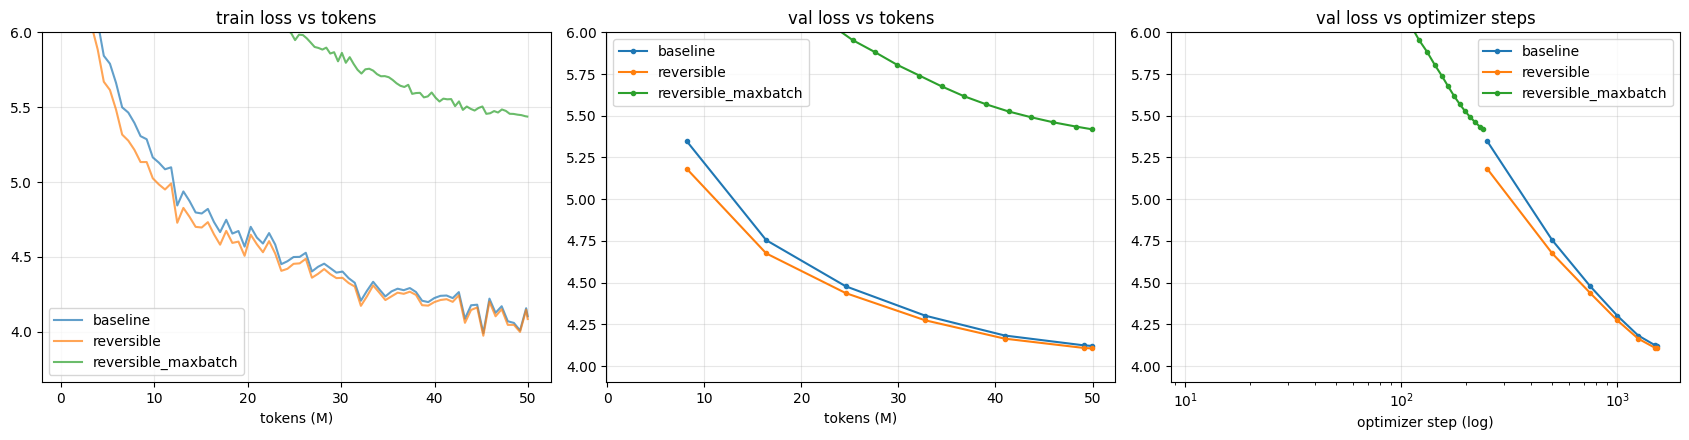

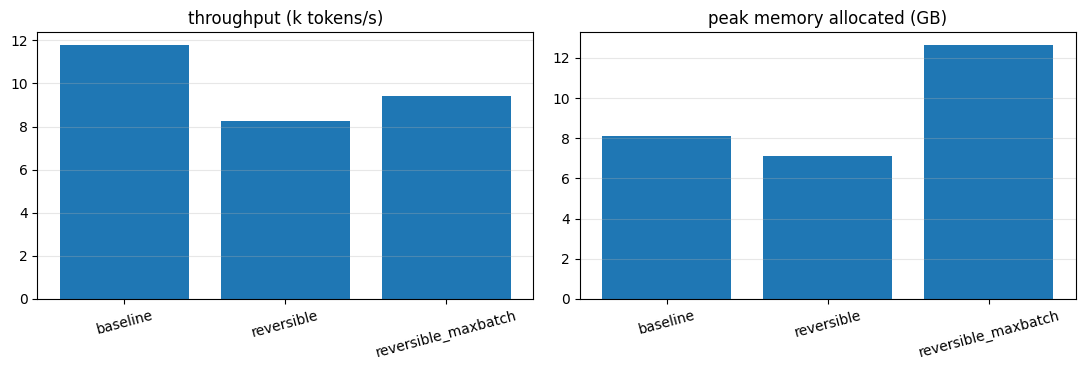

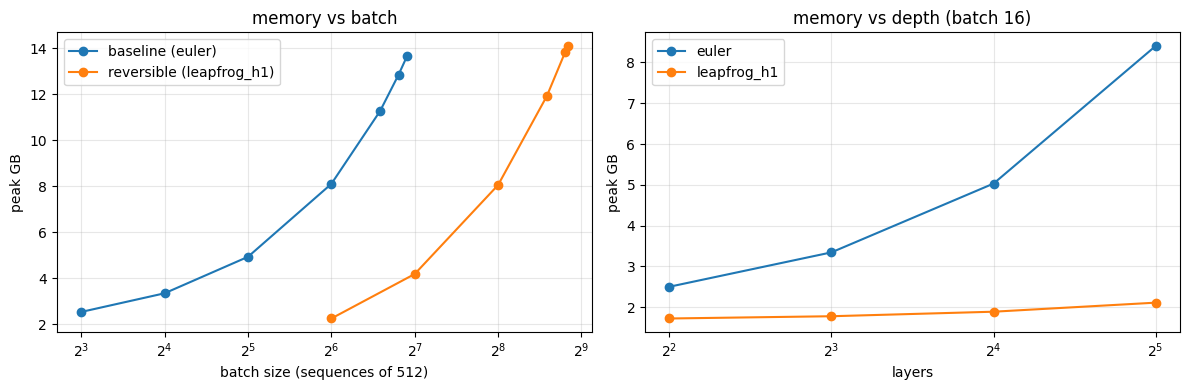

In [3]:
# loss vs tokens AND vs optimizer steps: the max-batch run sees the same tokens in far fewer steps
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for n, r in runs.items():
    ax[0].plot([h["tokens"]/1e6 for h in r["history"]], [h["loss"] for h in r["history"]], label=n, alpha=.7)
    ax[1].plot([e["tokens"]/1e6 for e in r["evals"]], [e["val_loss"] for e in r["evals"]], "o-", ms=3, label=n)
    ax[2].plot([e["step"] for e in r["evals"]], [e["val_loss"] for e in r["evals"]], "o-", ms=3, label=n)
for a, t, xl in zip(ax, ["train loss vs tokens", "val loss vs tokens", "val loss vs optimizer steps"],
                    ["tokens (M)", "tokens (M)", "optimizer step (log)"]):
    a.set_xlabel(xl); a.set_title(t); a.set_ylim(top=6); a.grid(alpha=.3); a.legend()
ax[2].set_xscale("log")
plt.tight_layout(); plt.savefig(f"{RESULTS}/loss_curves.png", dpi=120); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
names = list(runs)
ax[0].bar(names, [runs[n]["tokens_per_s"]/1e3 for n in names]); ax[0].set_title("throughput (k tokens/s)")
ax[1].bar(names, [runs[n]["peak_mem_allocated_gb"] for n in names]); ax[1].set_title("peak memory allocated (GB)")
for a in ax: a.tick_params(axis="x", rotation=15); a.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig(f"{RESULTS}/speed_memory.png", dpi=120); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for key, lab in [("trials", "baseline (euler)"), ("rev_trials", f"reversible ({vj.get('best_variant')})")]:
    t = {int(k): v for k, v in bj.get(key, {}).items() if v}
    if t: ax[0].plot(sorted(t), [t[k] for k in sorted(t)], "o-", label=lab)
ax[0].set_xscale("log", base=2); ax[0].set_xlabel("batch size (sequences of 512)"); ax[0].set_ylabel("peak GB"); ax[0].set_title("memory vs batch")
for k in [k for k in dep if k != "batch"]:
    t = {int(L): v for L, v in dep[k].items() if v}
    ax[1].plot(sorted(t), [t[L] for L in sorted(t)], "o-", label=k)
ax[1].set_xscale("log", base=2); ax[1].set_xlabel("layers"); ax[1].set_ylabel("peak GB"); ax[1].set_title(f"memory vs depth (batch {dep.get('batch')})")
for a in ax: a.grid(alpha=.3); a.legend()
plt.tight_layout(); plt.savefig(f"{RESULTS}/memory_vs_batch_depth.png", dpi=120); plt.show()

In [4]:
# copy results into the repo so they can be committed alongside the notebooks
if IN_COLAB:
    os.makedirs("results", exist_ok=True)   # git does not keep empty folders
    for f in glob.glob(f"{RESULTS}/*"):
        shutil.copy(f, "results/")
    !ls results

baseline.json		   reversible.json
batch.json		   reversible_maxbatch.json
drift_init.json		   saved_bytes_vs_depth.json
drift_trained.json	   speed_memory.png
loss_curves.png		   sweep_hamiltonian.json
mem_at_fixed_batch.json    sweep_leapfrog_h1.json
memory_vs_batch_depth.png  sweep_midpoint_a0.5_h0.25.json
mem_vs_depth.json	   sweep_midpoint_plain_h0.25.json
RESULTS.md		   variant.json
